In [56]:
import numpy as np
import matplotlib.pyplot as plt

In [57]:
from typing import Optional, Tuple


def wavenumber_positional_encoding(
        wavenumbers: np.ndarray,
        d_model: int,
        scale: float = 0.1,
        freq_scale: float = 1000,
        normalise: bool = True,
        global_range: Optional[Tuple[float, float]] = None,
) -> np.ndarray:
    """
    Generate sinusoidal positional encoding from wavenumber values.

    This encodes the actual wavenumber positions (e.g., 400-1800 cm^{-1})
    rather than array indices, preserving the physical meaning of the
    spectral axis.

    Parameters
    ----------
    wavenumbers : np.ndarray
        Wavenumber axis values, shape (n_wavenumbers,)
    d_model : int
        Embedding dimension (must be even)
    scale : float
        Output scaling factor
    normalise : bool
        If True, normalise wavenumbers to [0, 1] range before encoding.
        Recommended for typical positional encoding frequencies.
    global_range : tuple, optional
        (min, max) wavenumber range for normalisation.


    Returns
    -------
    np.ndarray
        Positional encoding, shape (n_wavenumbers, d_model)
    Notes
    -----
    Uses the standard transformer positional encoding:
        PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
        PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
        where pos = wavenumber (optionally normalised to [0, 1])
    """
    if d_model % 2 != 0:
        raise ValueError(f"d_model must be even, got {d_model}")

    # Normalise wavenumbers to [0, 1]
    if normalise:
        if global_range is not None:
            wn_min, wn_max = global_range
        else:
            wn_min, wn_max = wavenumbers.min(), wavenumbers.max()

        if wn_max == wn_min:
            position = np.zeros_like(wavenumbers)[:, np.newaxis]
        else:
            position = (wavenumbers - wn_min) / (wn_max - wn_min)
            position = position[:, np.newaxis]
    else:
        position = wavenumbers[:, np.newaxis]

    if normalise:
        position = position * freq_scale
    # Frequency scaling factors
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))

    # Sinusoidal encoding
    pe = np.zeros((len(wavenumbers), d_model))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)

    return pe * scale


def add_positional_encoding(
        data: np.ndarray,
        wavenumbers: Optional[np.ndarray] = None,
        d_model: int = 6,
        scale: float = 0.1,
        freq_scale: float = 1000,
        normalise: bool = True,
        per_sample: bool = False,
) -> np.ndarray:
    """
    Add wavenumber positional encoding to spectral data.

    Expands spectral intensities from (n_samples, n_wavenumbers) to
    (n_samples, n_wavenumbers, 1 + d_model) by concatenating the
    intensity channel with d_model positional encoding channels.

    Parameters
    ----------
    data :  np.ndarray
    wavenumbers : np.ndarray, optional
        Wavenumber axis. Required if data is np.ndarray.
        Can be shape (n_wavenumbers,) for shared axis or
        (n_samples, n_wavenumbers) for per-sample axes.
    d_model : int
        Positional encoding dimension (must be even)
    scale : float
        PE scaling factor
    normalise : bool
        Normalise wavenumbers before encoding
    per_sample : bool
        If True and wavenumbers vary per sample, generate PE per sample

    Returns
    -------
    np.ndarray
        Expanded data, shape (n_samples, n_wavenumbers, 1 + d_model)
        - Channel 0: Original intensities
        - Channels 1 to d_model: Positional encoding

    """

    if wavenumbers is None:
        raise ValueError("wavenumbers required when using numpy arrays")

    intensities = data
    wn = wavenumbers

    # Ensure 2D intensities
    if intensities.ndim == 1:
        intensities = intensities[np.newaxis, :]

    n_samples, n_wavenumbers = intensities.shape

    # Expand intensities to (n_samples, n_wavenumbers, 1)
    expanded = intensities[..., np.newaxis]

    # Compute global range for normalisation
    if normalise and wn.ndim == 2:
        global_min = np.min(wn)
        global_max = np.max(wn)
        global_range = (global_min, global_max)
        print(
            f"Computed global wavenumber range: [{global_min:.2f}, {global_max:.2f}] cm⁻¹"
        )
    else:
        global_range = None

    # Generate positional encoding
    if wn.ndim == 2 and per_sample:
        # Per-sample wavenumber axes with global normalization
        print("Generating per-sample positional encodings with global normalization...")
        pe_all = np.zeros((n_samples, n_wavenumbers, d_model))
        for i in range(n_samples):
            pe_all[i] = wavenumber_positional_encoding(
                wn[i], d_model, scale, freq_scale, normalise, global_range
            )
    else:
        # Shared wavenumber axis
        if wn.ndim == 2:
            print(
                "Using shared wavenumber axis from first sample for positional encoding."
            )
            # Use first sample's axis as representative
            wn = wn[0]
        pe = wavenumber_positional_encoding(wn, d_model, scale, freq_scale, normalise, global_range)
        pe_all = np.broadcast_to(pe[None, :, :], (n_samples, n_wavenumbers, d_model))

    # Concatenate intensity + PE
    return np.concatenate([expanded, pe_all], axis=-1)




In [58]:
# normalise = True
# scale = 0.1
# freq_scale = 736
# d_model = 8

# raman_pe = add_positional_encoding(sample_spectra_clean.intensities, sample_spectra.wavenumbers, scale=scale,
#                                    d_model=d_model, freq_scale=freq_scale, normalise=normalise)
# print(raman_pe.shape)


# raman_pe_channels = raman_pe[..., 1:]


# # Plot data + pe channels

# n = raman_pe.shape[-1]
# fig, ax = plt.subplots(nrows=n, ncols=1, figsize=(10, 10))
# time_index = raman_pe.shape[0] - 1
# for i in range(n):
#     ax[i].plot(wn,raman_pe[time_index, :, i], label=f"Dim {i}")
#     ax[i].set_title(f"Channel {i}")
#     ax[i].legend()
#     ax[i].grid()
# fig.tight_layout()

# plt.show()

## まずはテキトーなデータに対して試してみる

(5, 1000, 9)
(5, 1000, 8)


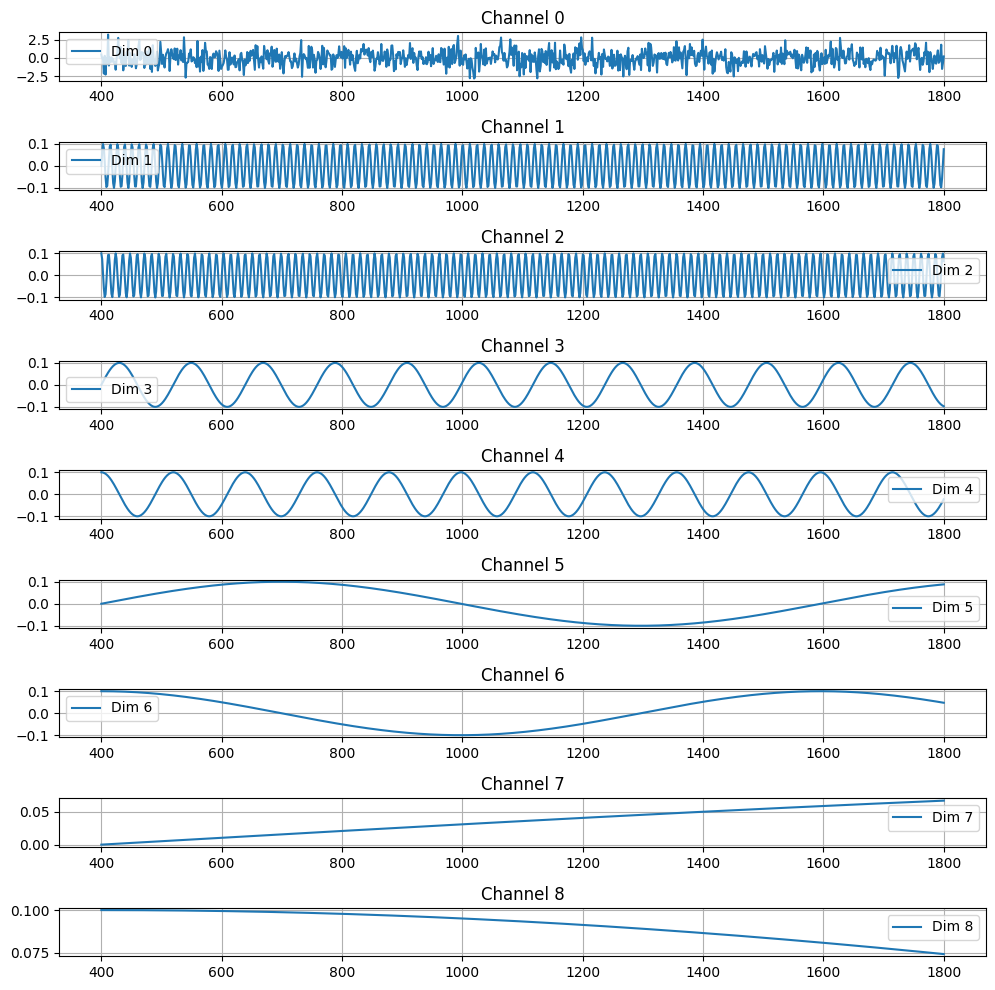

In [59]:
normalise = True
scale = 0.1
freq_scale = 736
d_model = 8


# 例: 5サンプル x 1000波数点
data = np.random.randn(5, 1000)
wavenumbers = np.linspace(400, 1800, 1000)
raman_pe = add_positional_encoding(
    data=data,
    wavenumbers=wavenumbers,
    d_model=d_model,       # 偶数必須
    scale=scale,
    freq_scale=freq_scale,
    normalise=normalise,
    per_sample=False
)

print(raman_pe.shape)  # (5, 1000, 9) = 1 + d_model


raman_pe_channels = raman_pe[..., 1:]
print(raman_pe_channels.shape)


# Plot data + pe channels

n = raman_pe.shape[-1]
fig, ax = plt.subplots(nrows=n, ncols=1, figsize=(10, 10))
time_index = raman_pe.shape[0] - 1
for i in range(n):
    ax[i].plot(wavenumbers,raman_pe[time_index, :, i], label=f"Dim {i}")
    ax[i].set_title(f"Channel {i}")
    ax[i].legend()
    ax[i].grid()
fig.tight_layout()

plt.show()

## 実際のデータに試す

In [60]:
noisy = np.load("../../data/after_prep_800-1000_artificial_noisy/artificial_noisy_7p5W.npy")
print("noisy.shape",noisy.shape)







noisy.shape (100, 200, 200)


In [61]:
d_model = 4

wavenumbers = np.linspace(800, 1000, 200)
# noisy: (N, T, W)
N, T, W = noisy.shape
assert W == len(wavenumbers), "wavenumbers長とnoisyの最後の次元を合わせてください"
# 1) 2Dへ
noisy_2d = noisy.reshape(N * T, W)  # (N*T, W)
# 2) 位置エンコーディングを付与
# add_positional_encoding は notebook内の関数を使用
noisy_pe_2d = add_positional_encoding(
    data=noisy_2d,
    wavenumbers=wavenumbers,  # shape: (W,)
    d_model=d_model,                # 偶数
    scale=10,
    freq_scale=100,
    normalise=True,
    per_sample=False
)  # (N*T, W, 1 + d_model)
# 3) 4Dへ戻す
noisy_pe = noisy_pe_2d.reshape(N, T, W, 1 + d_model)  # (100, 200, 200, 9)
print(noisy_pe.shape)



(100, 200, 200, 5)


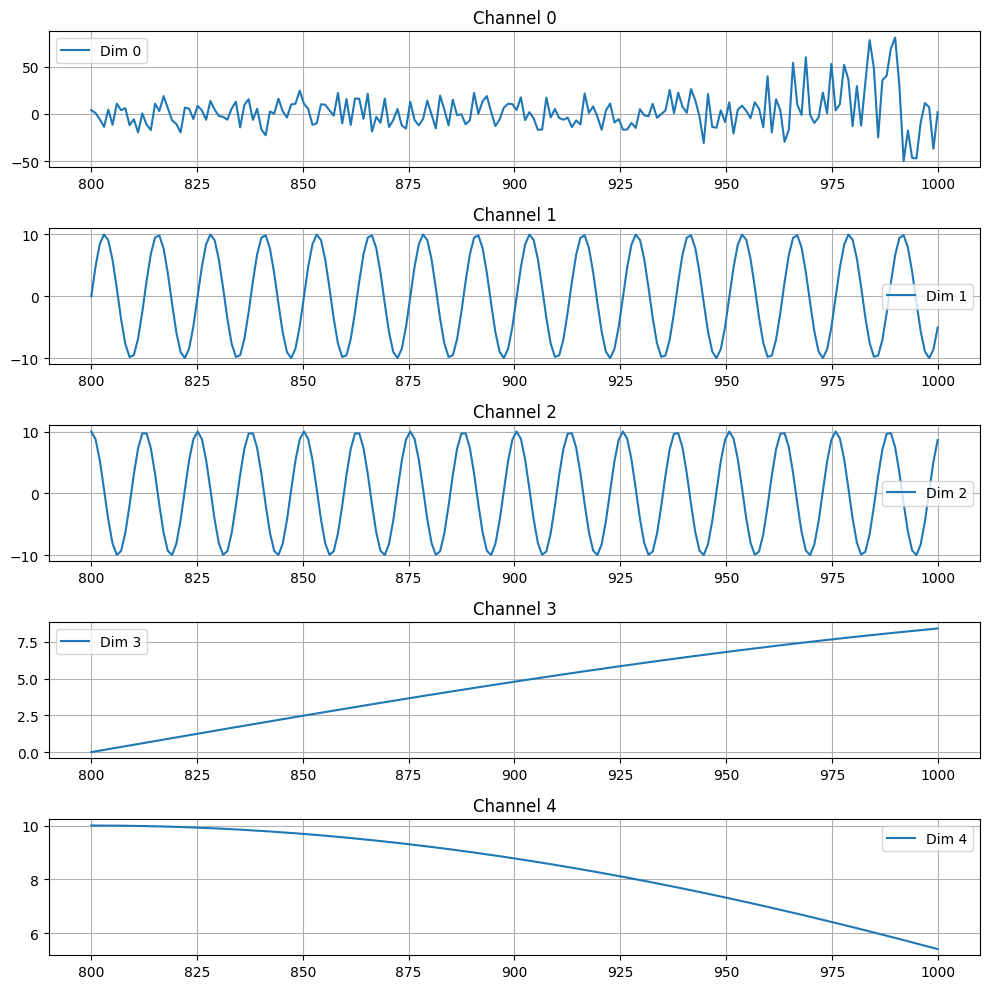

In [62]:
noisy_pe_3d = noisy_pe[1]
noisy_pe_channels = noisy_pe_3d[..., 1:]

# Plot data + pe channels
n = noisy_pe_3d.shape[-1]

fig, ax = plt.subplots(nrows=n, ncols=1, figsize=(10, 10))
time_index = noisy_pe_3d.shape[0] - 1

for i in range(n):
    ax[i].plot(wavenumbers, noisy_pe_3d[time_index, :, i], label=f"Dim {i}")
    ax[i].set_title(f"Channel {i}")
    ax[i].legend()
    ax[i].grid()

fig.tight_layout()
plt.show()